# Canada Vapes Operations Analysis

## tl;dr

Only about **24.6%** of customers were active within 90 days of the snapshot; approximately **27.9%** fall in the 91–365-day intervention window and **47.5%** are more than one year inactive. Operations should use tiered service and reactivation queues rather than one universal cadence. The analysis-ready file still contains 292 review records, mainly zero-spend positive-order and missing-location/date cases.

## Context & methods

This notebook treats customer recency as CRM workload, not physical order demand. It supports customer-service and data-governance operations. Inventory, warehouse and delivery planning require transaction, SKU, order-status and fulfillment timestamps that are not present here.

### 1. Setup and locate the analysis-ready file

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

COLORS = {
    "blue": "#35648F",
    "gold": "#C89B32",
    "orange": "#CC6B3D",
    "olive": "#7F8C55",
    "ink": "#2F3742",
    "grey": "#AAB4BF",
    "light": "#E7ECF1",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": COLORS["ink"],
    "axes.labelcolor": COLORS["ink"],
    "axes.titlecolor": COLORS["ink"],
    "xtick.color": COLORS["ink"],
    "ytick.color": COLORS["ink"],
    "text.color": COLORS["ink"],
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.color": "#D7DCE1",
    "grid.alpha": 0.75,
    "grid.linewidth": 0.8,
})

def find_data_file() -> Path:
    candidates = []
    configured = os.environ.get("CANADA_VAPES_ANALYSIS_FILE")
    if configured:
        candidates.append(Path(configured))
    candidates.extend([
        Path.cwd() / "CanadaVapes_analysis_ready.csv",
        Path.cwd() / "upload" / "CanadaVapes_analysis_ready.csv",
        Path("C:/Users/tooko/Downloads/canadavape/CanadaVapes_analysis_ready.csv"),
        Path("C:/Users/tooko/Downloads/canada vape/CanadaVapes_analysis_ready.csv"),
    ])
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    checked = "\n".join(f"  - {candidate}" for candidate in candidates)
    raise FileNotFoundError(
        "CanadaVapes_analysis_ready.csv was not found. Checked:\n" + checked
    )

DATA_FILE = find_data_file()
BASE_OUTPUT_FOLDER = DATA_FILE.parent / "CanadaVapes_strategic_outputs"
BASE_OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

def money(value: float) -> str:
    return f"${value:,.0f}"

def percent(value: float) -> str:
    return f"{value:.1%}"

def finish_axis(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)

print("Analysis-ready data:", DATA_FILE)
print("Output folder:", BASE_OUTPUT_FOLDER)

Analysis-ready data: C:\Users\tooko\Downloads\CanadaVapes_analysis_ready.csv
Output folder: C:\Users\tooko\Downloads\CanadaVapes_strategic_outputs


### 2. Load and validate customer data

In [2]:
required_columns = {
    "customer_record_id", "last_active", "sign_up", "orders", "total_spend",
    "aov", "city", "region", "days_since_last_active",
    "customer_tenure_days", "record_quality_status", "data_quality_issue",
}

df = pd.read_csv(
    DATA_FILE,
    encoding="utf-8-sig",
    parse_dates=["last_active", "sign_up"],
)

missing_columns = sorted(required_columns - set(df.columns))
if missing_columns:
    raise ValueError("Required columns are missing: " + ", ".join(missing_columns))

for column in ["orders", "total_spend", "aov", "days_since_last_active", "customer_tenure_days"]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

if df["customer_record_id"].duplicated().any():
    raise ValueError("customer_record_id is not unique.")
if df[["orders", "total_spend", "aov", "days_since_last_active"]].isna().any().any():
    raise ValueError("Core analysis fields contain missing or invalid numbers.")
if (df[["orders", "total_spend", "aov"]].lt(0)).any().any():
    raise ValueError("The analysis-ready file still contains negative core values.")

snapshot_date = df["last_active"].max().normalize()
df["is_repeat_customer"] = df["orders"].ge(2)
df["is_active_90d"] = df["days_since_last_active"].le(90)

print(f"Rows loaded: {len(df):,}")
print(f"Snapshot date: {snapshot_date.date()}")
display(df[[
    "customer_record_id", "last_active", "orders", "total_spend", "aov",
    "city", "region", "days_since_last_active"
]].head())

Rows loaded: 30,803
Snapshot date: 2026-07-08


,customer_record_id,last_active,orders,total_spend,aov,city,region,days_since_last_active
0,CV-000001,2026-07-08 15:31:03,11,"1,140.69",103.70,Neuville,QC,0
1,CV-000002,2026-07-08 15:29:52,54,"8,902.99",164.87,Niagara Falls,ON,0
2,CV-000003,2026-07-08 15:28:42,18,"2,713.19",150.73,Glencoe,ON,0
3,CV-000004,2026-07-08 15:28:26,2,180.64,90.32,Laval,QC,0
4,CV-000005,2026-07-08 15:26:59,49,"6,284.21",128.25,Port Medway,NS,0


### 3. Create operational recency and priority groups

In [3]:
OPERATIONS_FOLDER = BASE_OUTPUT_FOLDER / "operations"
OPERATIONS_FOLDER.mkdir(parents=True, exist_ok=True)

recency_bins = [-1, 30, 60, 90, 180, 365, 730, np.inf]
recency_labels = ["0–30 days", "31–60 days", "61–90 days", "91–180 days", "181–365 days", "366–730 days", "731+ days"]
df["recency_band"] = pd.cut(df["days_since_last_active"], bins=recency_bins, labels=recency_labels)
df["activity_group"] = np.select(
    [df["days_since_last_active"].le(90), df["days_since_last_active"].le(365)],
    ["Active ≤90 days", "Due 91–365 days"],
    default="Dormant >365 days",
)

frequency_q75 = float(df["orders"].quantile(0.75))
monetary_q75 = float(df["total_spend"].quantile(0.75))
high_value = df["orders"].ge(frequency_q75) | df["total_spend"].ge(monetary_q75)

priority_conditions = [
    df["days_since_last_active"].le(90) & high_value,
    df["days_since_last_active"].between(91, 365) & high_value,
    df["days_since_last_active"].le(90),
    df["days_since_last_active"].between(91, 365),
    df["days_since_last_active"].gt(365) & high_value,
]
priority_names = [
    "P1 Active high value", "P2 Due high value", "P3 Active standard",
    "P4 Due standard", "P5 Dormant high value",
]
df["operational_priority"] = np.select(priority_conditions, priority_names, default="P6 Dormant standard")

df.to_csv(OPERATIONS_FOLDER / "operations_customer_priority_queue.csv", index=False, encoding="utf-8-sig")

recency_summary = (
    df.groupby("recency_band", observed=True, as_index=False)
    .agg(customers=("customer_record_id", "size"), lifetime_spend=("total_spend", "sum"), total_orders=("orders", "sum"))
)
recency_summary["customer_share"] = recency_summary["customers"] / len(df)
recency_summary.to_csv(OPERATIONS_FOLDER / "operations_recency_summary.csv", index=False, encoding="utf-8-sig")
display(recency_summary)

,recency_band,customers,lifetime_spend,total_orders,customer_share
0,0–30 days,3973,"8,467,955.96",60757,0.13
1,31–60 days,2070,"2,845,075.48",19978,0.07
2,61–90 days,1527,"1,238,214.55",9362,0.05
3,91–180 days,3380,"1,767,632.71",14773,0.11
4,181–365 days,5211,"2,345,165.85",20285,0.17
5,366–730 days,10150,"3,200,667.67",31074,0.33
6,731+ days,4492,"870,179.68",9129,0.15


### 4. Visualize the customer-activity backlog

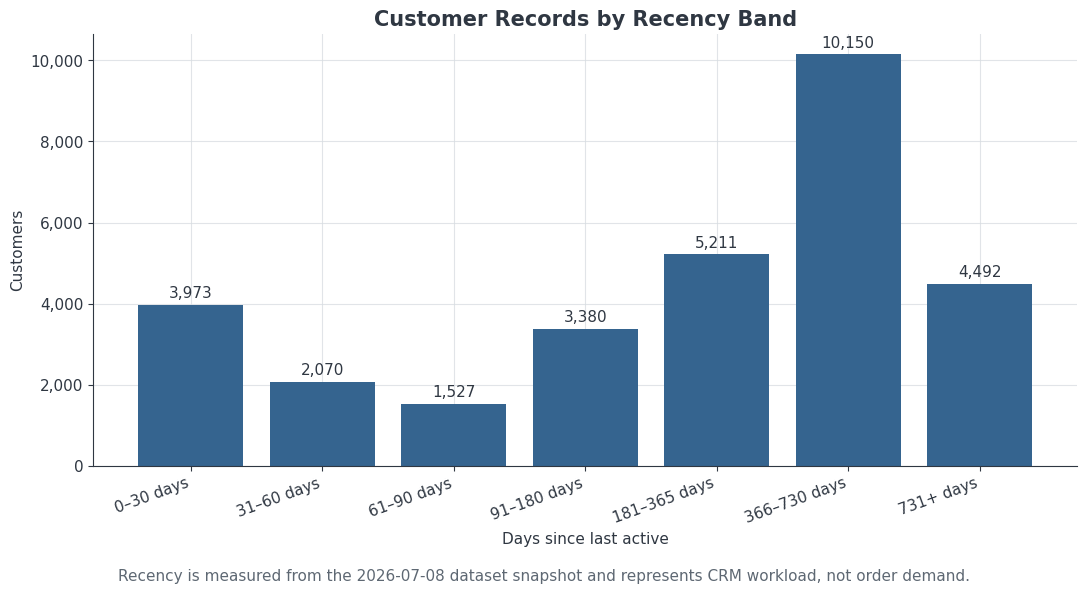

In [4]:
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(recency_summary["recency_band"].astype(str), recency_summary["customers"], color=COLORS["blue"])
ax.set_title("Customer Records by Recency Band")
ax.set_xlabel("Days since last active")
ax.set_ylabel("Customers")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in recency_summary["customers"]], padding=3)
finish_axis(ax)
fig.text(0.5, 0.02, "Recency is measured from the 2026-07-08 dataset snapshot and represents CRM workload, not order demand.", ha="center", color="#5E6873")
plt.xticks(rotation=20, ha="right")
plt.tight_layout(rect=[0, 0.05, 1, 1])
CHART_FILE = OPERATIONS_FOLDER / "01_recency_backlog.png"
fig.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.show()

### 5. Build the regional workload matrix

In [5]:
region_workload = (
    df.assign(region=df["region"].fillna("Unknown"))
    .pivot_table(index="region", columns="activity_group", values="customer_record_id", aggfunc="count", fill_value=0)
    .reset_index()
)
for column in ["Active ≤90 days", "Due 91–365 days", "Dormant >365 days"]:
    if column not in region_workload:
        region_workload[column] = 0
region_workload["total_customers"] = region_workload[["Active ≤90 days", "Due 91–365 days", "Dormant >365 days"]].sum(axis=1)
region_workload["active_share"] = region_workload["Active ≤90 days"] / region_workload["total_customers"]
region_workload["due_share"] = region_workload["Due 91–365 days"] / region_workload["total_customers"]
region_workload = region_workload.sort_values("total_customers", ascending=False)
region_workload.to_csv(OPERATIONS_FOLDER / "regional_customer_workload.csv", index=False, encoding="utf-8-sig")
display(region_workload)

activity_group,region,Active ≤90 days,Dormant >365 days,Due 91–365 days,total_customers,active_share,due_share
8,ON,2009,4705,2312,9026,0.22,0.26
10,QC,2089,3637,2188,7914,0.26,0.28
1,BC,837,2042,1158,4037,0.21,0.29
5,NS,1074,1494,1183,3751,0.29,0.32
0,AB,509,1022,606,2137,0.24,0.28
3,NB,393,515,410,1318,0.30,0.31
9,PE,187,254,153,594,0.31,0.26
2,MB,121,304,149,574,0.21,0.26
11,SK,141,266,157,564,0.25,0.28
4,NL,126,218,151,495,0.25,0.31


### 6. Visualize regional active, due and dormant workload

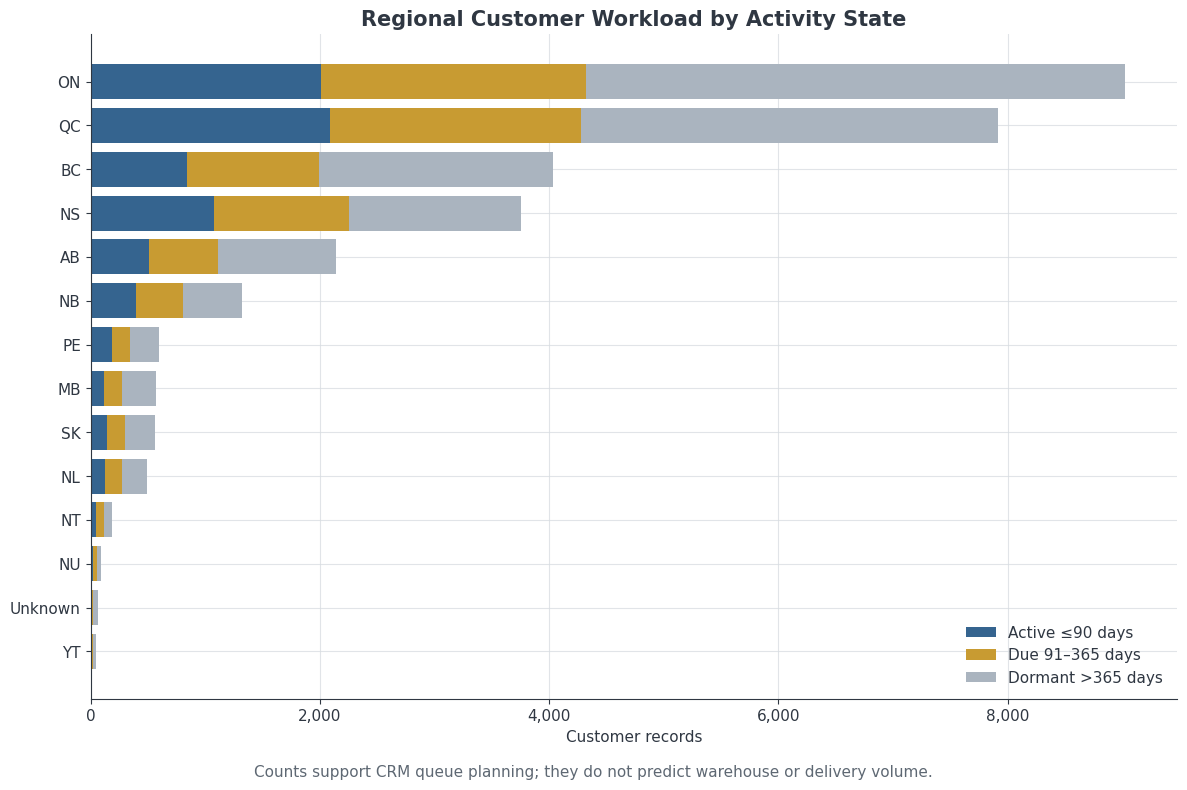

In [6]:
region_plot = region_workload.sort_values("total_customers", ascending=True)
fig, ax = plt.subplots(figsize=(12, 8))
left_active = np.zeros(len(region_plot))
for column, color in zip(
    ["Active ≤90 days", "Due 91–365 days", "Dormant >365 days"],
    [COLORS["blue"], COLORS["gold"], COLORS["grey"]],
):
    ax.barh(region_plot["region"], region_plot[column], left=left_active, label=column, color=color)
    left_active = left_active + region_plot[column].to_numpy()
ax.set_title("Regional Customer Workload by Activity State")
ax.set_xlabel("Customer records")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(frameon=False, loc="lower right")
finish_axis(ax)
fig.text(0.5, 0.02, "Counts support CRM queue planning; they do not predict warehouse or delivery volume.", ha="center", color="#5E6873")
plt.tight_layout(rect=[0, 0.04, 1, 1])
CHART_FILE = OPERATIONS_FOLDER / "02_regional_workload.png"
fig.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.show()

### 7. Prioritize customer-service and reactivation work

In [7]:
priority_order = [
    "P1 Active high value", "P2 Due high value", "P3 Active standard",
    "P4 Due standard", "P5 Dormant high value", "P6 Dormant standard",
]
priority_summary = (
    df.groupby("operational_priority", as_index=False)
    .agg(customers=("customer_record_id", "size"), lifetime_spend=("total_spend", "sum"), total_orders=("orders", "sum"), median_recency_days=("days_since_last_active", "median"))
)
priority_summary["operational_priority"] = pd.Categorical(priority_summary["operational_priority"], categories=priority_order, ordered=True)
priority_summary = priority_summary.sort_values("operational_priority")
priority_summary.to_csv(OPERATIONS_FOLDER / "operational_priority_summary.csv", index=False, encoding="utf-8-sig")
display(priority_summary)

,operational_priority,customers,lifetime_spend,total_orders,median_recency_days
0,P1 Active high value,4330,"12,026,976.94",84293,22.00
1,P2 Due high value,2251,"3,215,681.39",24828,206.00
2,P3 Active standard,3240,"524,269.05",5804,39.00
3,P4 Due standard,6340,"897,117.17",10230,215.00
4,P5 Dormant high value,2112,"2,552,584.53",22046,418.00
5,P6 Dormant standard,12530,"1,518,262.82",18157,499.00


### 8. Visualize priority workload and historical value

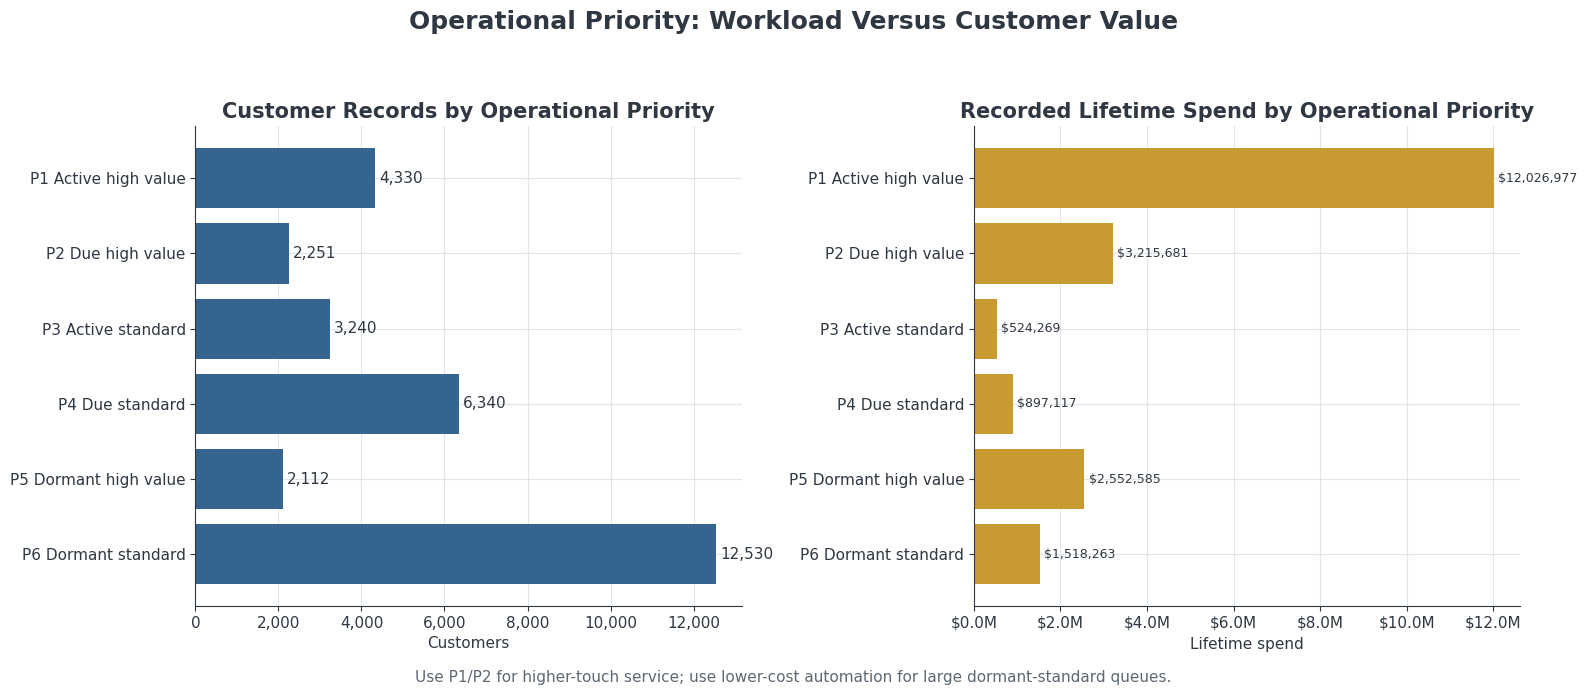

In [8]:
priority_plot = priority_summary.iloc[::-1]
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

bars1 = axes[0].barh(priority_plot["operational_priority"].astype(str), priority_plot["customers"], color=COLORS["blue"])
axes[0].set_title("Customer Records by Operational Priority")
axes[0].set_xlabel("Customers")
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[0].bar_label(bars1, labels=[f"{v:,.0f}" for v in priority_plot["customers"]], padding=3)
finish_axis(axes[0])

bars2 = axes[1].barh(priority_plot["operational_priority"].astype(str), priority_plot["lifetime_spend"], color=COLORS["gold"])
axes[1].set_title("Recorded Lifetime Spend by Operational Priority")
axes[1].set_xlabel("Lifetime spend")
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M"))
axes[1].bar_label(bars2, labels=[money(v) for v in priority_plot["lifetime_spend"]], padding=3, fontsize=9)
finish_axis(axes[1])

fig.suptitle("Operational Priority: Workload Versus Customer Value", fontsize=18, fontweight="bold")
fig.text(0.5, 0.02, "Use P1/P2 for higher-touch service; use lower-cost automation for large dormant-standard queues.", ha="center", color="#5E6873")
plt.tight_layout(rect=[0, 0.04, 1, 0.93])
CHART_FILE = OPERATIONS_FOLDER / "03_priority_workload_and_value.png"
fig.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.show()

### 9. Audit remaining data-quality review workload

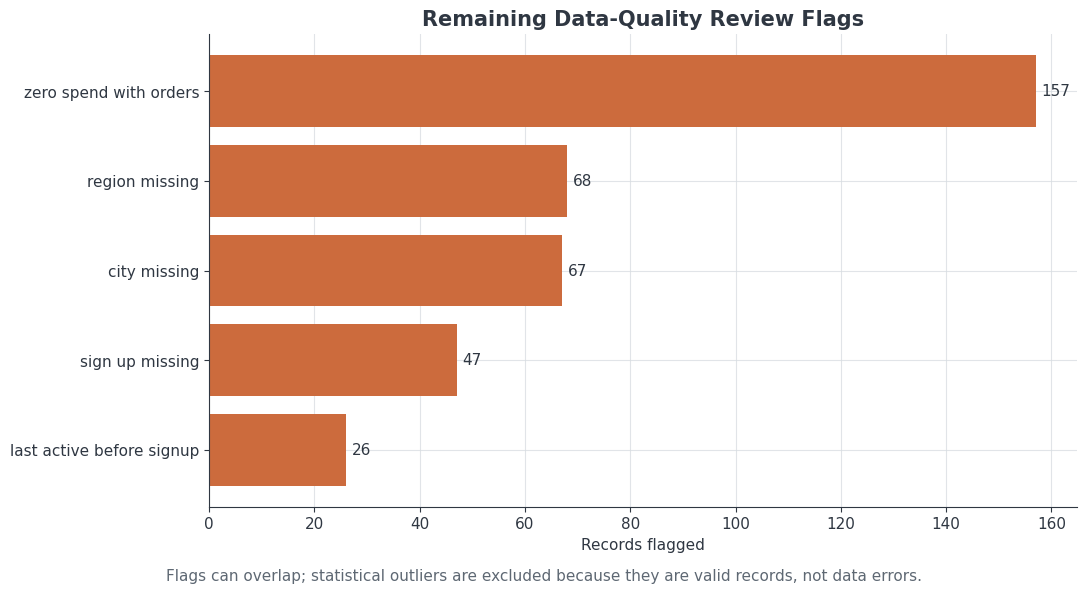

,quality_flag,records
0,zero_spend_with_orders_flag,157
1,region_missing_flag,68
2,city_missing_flag,67
3,sign_up_missing_flag,47
4,last_active_before_signup_flag,26


In [9]:
quality_flag_columns = [
    column for column in [
        "sign_up_missing_flag", "city_missing_flag", "region_missing_flag",
        "last_active_before_signup_flag", "zero_spend_with_orders_flag",
        "aov_mismatch_flag", "future_last_active_flag", "future_sign_up_flag",
    ] if column in df.columns
]
quality_counts = df[quality_flag_columns].fillna(False).astype(bool).sum().sort_values(ascending=False)
quality_counts = quality_counts[quality_counts.gt(0)]

quality_review_queue = df.loc[df["data_quality_issue"].fillna(False).astype(bool)].copy()
quality_review_queue.to_csv(OPERATIONS_FOLDER / "operations_data_quality_review_queue.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(11, 6))
quality_plot = quality_counts.sort_values(ascending=True)
bars = ax.barh(quality_plot.index.str.replace("_flag", "", regex=False).str.replace("_", " "), quality_plot.values, color=COLORS["orange"])
ax.set_title("Remaining Data-Quality Review Flags")
ax.set_xlabel("Records flagged")
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in quality_plot.values], padding=4)
finish_axis(ax)
fig.text(0.5, 0.02, "Flags can overlap; statistical outliers are excluded because they are valid records, not data errors.", ha="center", color="#5E6873")
plt.tight_layout(rect=[0, 0.04, 1, 1])
CHART_FILE = OPERATIONS_FOLDER / "04_data_quality_review.png"
fig.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.show()

display(pd.DataFrame({"quality_flag": quality_counts.index, "records": quality_counts.values}))

## Strategic recommendations

In [10]:
activity_counts = df["activity_group"].value_counts()
active_share = activity_counts.get("Active ≤90 days", 0) / len(df)
due_share = activity_counts.get("Due 91–365 days", 0) / len(df)
dormant_share = activity_counts.get("Dormant >365 days", 0) / len(df)
review_count = len(quality_review_queue)

operations_recommendations = pd.DataFrame([
    {
        "priority": 1,
        "recommendation": "Run tiered CRM queues instead of one universal contact cadence",
        "evidence": f"Customer mix is {active_share:.1%} active, {due_share:.1%} due and {dormant_share:.1%} dormant.",
        "operating_action": "P1/P2 receive higher-touch handling; P4/P6 use lower-cost automation",
    },
    {
        "priority": 2,
        "recommendation": "Protect the due high-value queue before broad dormant reactivation",
        "evidence": f"{int(priority_summary.loc[priority_summary['operational_priority'].eq('P2 Due high value'), 'customers'].iloc[0]):,} customers are both due and high value.",
        "operating_action": "Set weekly ownership, SLA and conversion reporting for P2 records",
    },
    {
        "priority": 3,
        "recommendation": "Resolve customer master-data defects at source",
        "evidence": f"{review_count:,} analysis-ready records still require review; zero-spend and location/date gaps dominate.",
        "operating_action": "Require stable customer ID, valid region and source timestamps; investigate zero-spend orders",
    },
    {
        "priority": 4,
        "recommendation": "Add operational event data before inventory or staffing forecasts",
        "evidence": "Customer lifetime totals cannot measure SKU demand, processing time, refunds, stockouts or delivery workload.",
        "operating_action": "Capture order date, SKU, quantity, status, warehouse, ship date, delivery date and refund reason",
    },
])
operations_recommendations.to_csv(OPERATIONS_FOLDER / "operations_strategic_recommendations.csv", index=False, encoding="utf-8-sig")
display(operations_recommendations)

,priority,recommendation,evidence,operating_action
0,1,Run tiered CRM queues instead of one universal...,"Customer mix is 24.6% active, 27.9% due and 47...",P1/P2 receive higher-touch handling; P4/P6 use...
1,2,Protect the due high-value queue before broad ...,"2,251 customers are both due and high value.","Set weekly ownership, SLA and conversion repor..."
2,3,Resolve customer master-data defects at source,292 analysis-ready records still require revie...,"Require stable customer ID, valid region and s..."
3,4,Add operational event data before inventory or...,Customer lifetime totals cannot measure SKU de...,"Capture order date, SKU, quantity, status, war..."


## Validation and limitations

In [11]:
assert int(recency_summary["customers"].sum()) == len(df)
assert int(region_workload["total_customers"].sum()) == len(df)
assert int(priority_summary["customers"].sum()) == len(df)
assert len(quality_review_queue) == int(df["data_quality_issue"].fillna(False).astype(bool).sum())

validation = pd.DataFrame({
    "check": ["Recency reconciliation", "Regional workload reconciliation", "Priority reconciliation", "Data-quality queue reconciliation", "Forecast scope"],
    "result": ["Passed", "Passed", "Passed", "Passed", "CRM workload only; inventory/staffing forecast requires operational events"],
})
display(validation)

,check,result
0,Recency reconciliation,Passed
1,Regional workload reconciliation,Passed
2,Priority reconciliation,Passed
3,Data-quality queue reconciliation,Passed
4,Forecast scope,CRM workload only; inventory/staffing forecast...
